=== Dataset Loaded ===
   StudentID  Gender  Age  StudyHoursPerWeek  AttendanceRate   GPA      Major  \
0          1    Male   24                 37           90.75  3.47       Arts   
1          2  Female   22                 37           74.90  2.32  Education   
2          3    Male   22                 10           53.36  2.38   Business   
3          4    Male   24                 10           70.26  3.46    Science   
4          5    Male   18                 19           74.87  2.31  Education   

  PartTimeJob ExtraCurricularActivities  
0         Yes                        No  
1          No                        No  
2          No                        No  
3         Yes                        No  
4         Yes                        No  

=== Correlation Matrix ===
                   StudyHoursPerWeek  AttendanceRate       GPA
StudyHoursPerWeek           1.000000        0.095716  0.091700
AttendanceRate              0.095716        1.000000  0.060828
GPA                  

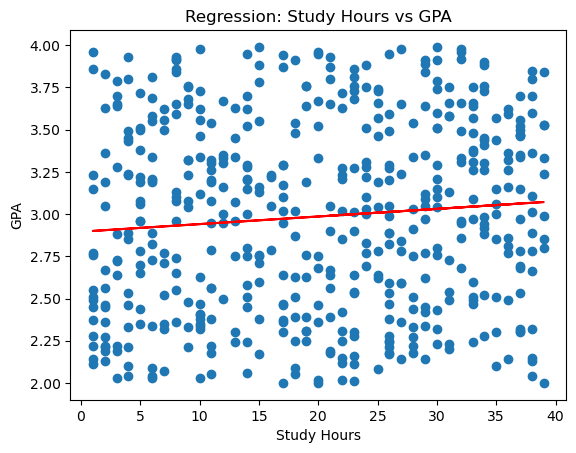

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Step 1: Load Dataset
df = pd.read_csv("student_performance_data.csv")

print("=== Dataset Loaded ===")
print(df.head())


# Step 2: Correlation
# Concept:
# Correlation shows relationship between variables (-1 to +1)

corr_matrix = df[['StudyHoursPerWeek', 'AttendanceRate', 'GPA']].corr()

print("\n=== Correlation Matrix ===")
print(corr_matrix)


# Step 3: Regression Model
# Concept:
# Regression finds equation: Y = mX + c

# Input (Feature)
X = df[['StudyHoursPerWeek']]

# Output (Target)
Y = df['GPA']

model = LinearRegression()
model.fit(X, Y)

m = model.coef_[0]      # slope
c = model.intercept_   # intercept
r_sq = model.score(X, Y)

print("\n=== Regression Parameters ===")
print("Slope (m):", m)
print("Intercept (c):", c)
print("R-Squared:", round(r_sq, 4))

# Step 4: Prediction
# Concept:
# Predict output for new input value

new_input = pd.DataFrame({'StudyHoursPerWeek': [20]})

prediction = model.predict(new_input)

print("\n=== Prediction ===")
print("Predicted GPA:", round(prediction[0], 2))


# Step 5: Visualization
# Concept:
# Scatter plot + regression line shows relationship

plt.figure()

plt.scatter(df['StudyHoursPerWeek'], df['GPA'])

# Regression line
predicted_line = model.predict(X)
plt.plot(df['StudyHoursPerWeek'], predicted_line,color = "red")

plt.title("Regression: Study Hours vs GPA")
plt.xlabel("Study Hours")
plt.ylabel("GPA")

plt.show()